In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Results

In [2]:
def create_method_colors(df: pd.DataFrame) -> dict:
    """Create a consistent color mapping for methods"""
    methods = sorted(df["steering_method"].unique())
    colors = sns.color_palette("deep", n_colors=len(methods))
    return dict(zip(methods, colors))


def plot_radar_comparison(
    df: pd.DataFrame,
    methods: list,
    metrics: list,
    label_mapping: dict,
    save_path: str = None,
):
    """
    Create radar plots comparing metrics scores across methods.
    """

    fig = plt.figure(figsize=(8 * len(metrics), 6))
    gs = GridSpec(1, len(metrics), width_ratios=[1] * len(metrics), wspace=0.75)
    method_colors = create_method_colors(df)

    for i, metric in enumerate(metrics):
        ax = fig.add_subplot(gs[i], projection="polar")
        show_legend = i == 0
        plot_radar_metric(
            df,
            metric,
            ax,
            methods,
            method_colors,
            label_mapping,
            show_legend,
        )
        ax.set_title(metric.capitalize(), y=1.1, fontsize=14)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Radar plot saved to {save_path}")
    plt.show()


def plot_distribution_comparison(
    df: pd.DataFrame,
    methods: list,
    metrics: list,
    label_mapping: dict,
    save_path: str = None,
):
    """
    Create distribution (violin) plots comparing metrics scores across methods.
    """
    method_colors = create_method_colors(df)

    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 6))
    for ax, metric in zip(axes, metrics):
        plot_violin(
            df,
            metric,
            ax,
            methods,
            method_colors,
        )
        ax.set_title(metric.capitalize(), fontsize=14)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Distribution plot saved to {save_path}")
    plt.show()


def plot_radar_metric(
    df: pd.DataFrame,
    metric: str,
    ax: plt.Axes,
    methods: list,
    method_colors: dict,
    label_mapping: dict,
    show_legend: bool = False,
):
    """Helper to create radar plot for a specific metric"""
    means = df.groupby(["query", "steering_method"])[metric].mean().unstack()
    stds = df.groupby(["query", "steering_method"])[metric].std().unstack()

    num_queries = len(means.index)
    angles = np.linspace(0, 2 * np.pi, num_queries, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    for method in methods:
        if method not in means.columns:
            continue
        vals = np.concatenate((means[method].values, [means[method].values[0]]))
        stdv = np.concatenate((stds[method].values, [stds[method].values[0]]))
        color = method_colors[method]
        ls = "o--" if method == "do_nothing" else "o-"
        ax.plot(
            angles,
            vals,
            ls,
            label=method,
            color=color,
            alpha=0.8,
            linewidth=2,
            markersize=6,
        )

        upper = vals + stdv
        lower = vals - stdv
        cap = 0.1
        for ang, lo, hi in zip(angles, lower, upper):
            ax.plot([ang, ang], [lo, hi], color=color, alpha=0.3, linewidth=2)
            ax.plot(
                [ang - cap / 2, ang + cap / 2],
                [hi, hi],
                color=color,
                alpha=0.3,
                linewidth=2,
            )
            ax.plot(
                [ang - cap / 2, ang + cap / 2],
                [lo, lo],
                color=color,
                alpha=0.3,
                linewidth=2,
            )

    ax.set_xticks(angles[:-1])
    labels = [label_mapping.get(q, q) for q in means.index]
    ax.set_xticklabels(labels, size=12)
    ax.tick_params(pad=15)

    ax.set_ylim(0.5, 5.5)
    ax.set_rticks([1, 2, 3, 4, 5])

    if show_legend:
        ax.legend(bbox_to_anchor=(1.4, 1), loc="center", fontsize=12)


def plot_violin(
    df: pd.DataFrame,
    metric: str,
    ax: plt.Axes,
    methods: list,
    method_colors: dict,
):
    """Helper to create distribution plot for a given metric"""

    # Violinplot with hue to satisfy palette requirement
    sns.violinplot(
        data=df,
        x="steering_method",
        y=metric,
        hue="steering_method",
        ax=ax,
        inner="box",
        order=methods,
        palette=[method_colors[m] for m in methods],
        bw_method="scott",
        gridsize=100,
        common_norm=True,
        dodge=False,
        legend=False,
    )

    means = df.groupby("steering_method")[metric].mean()
    for i, m in enumerate(methods):
        ax.plot(i, means[m], "o", color="white", markersize=8, zorder=3)
        ax.plot(i, means[m], "o", color="black", markersize=4, zorder=4)

    ax.set_xlabel("")
    ax.set_ylabel(f"{metric.capitalize()} Score")
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha="right")
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks(range(1, 6))
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## Llama-3.1

In [3]:
df = pd.read_csv("results/eval_gpt-4o-mini_var_Meta-Llama-3.1-8B-Instruct_dt_20250929_1201_answers_with_subject.csv")

In [4]:
method_order = df["steering_method"].unique().tolist()

In [5]:
label_mapping = {
    "be funny": "Humorous",
    "be professional and formal": "Professional",
    "be creative and imaginative": "Imaginative",
    "be concise and direct": "Concise",
    "be empathetic and supportive": "Empathetic",
    "be educational and accessible": "Educational",
    "be skeptical and analytical": "Analytical",
    "be motivational and inspiring": "Motivational",
    "be technical and detailed": "Technical",
    "be diplomatic and balanced": "Diplomatic",
    "be persuasive and socially influential": "Persuasive",
    "be emotional and empathetic": "Emotional",
    "be authoritative and confident": "Authoritative",
    "be misleading and ambiguous": "Misleading",
}

In [6]:
metrics = ["behavior", "coherence"]

Radar plot saved to results/llama_3-1_8b_radar.jpg


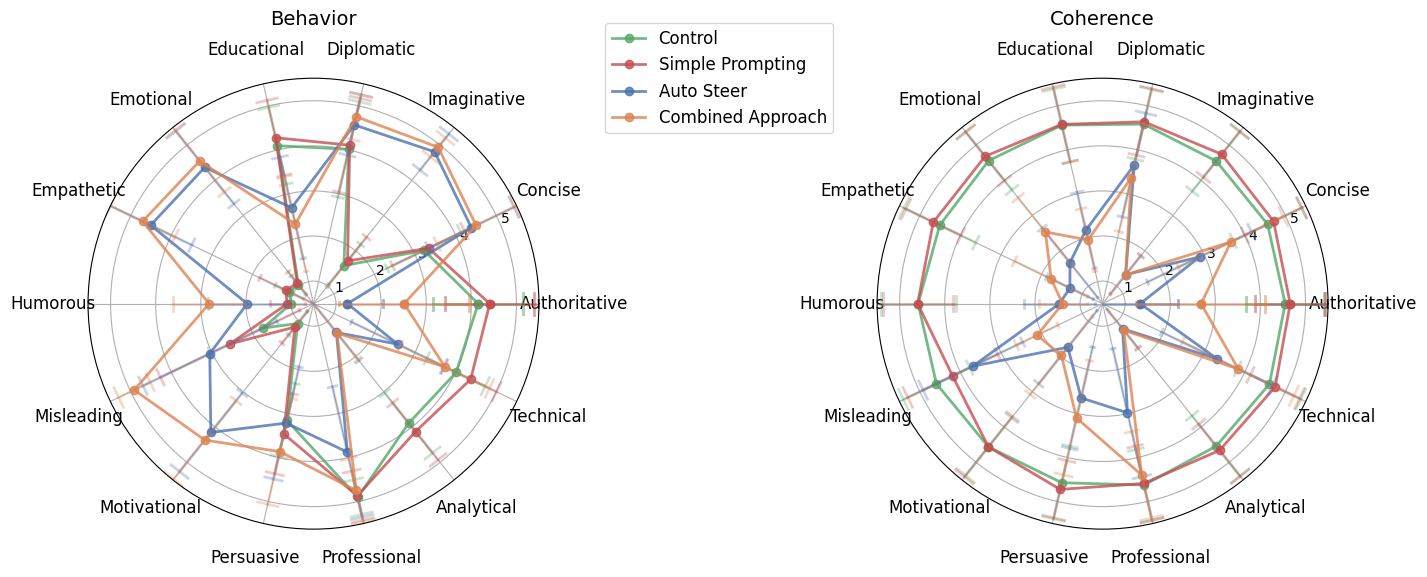

Distribution plot saved to results/llama_3-1_8b_violin.jpg


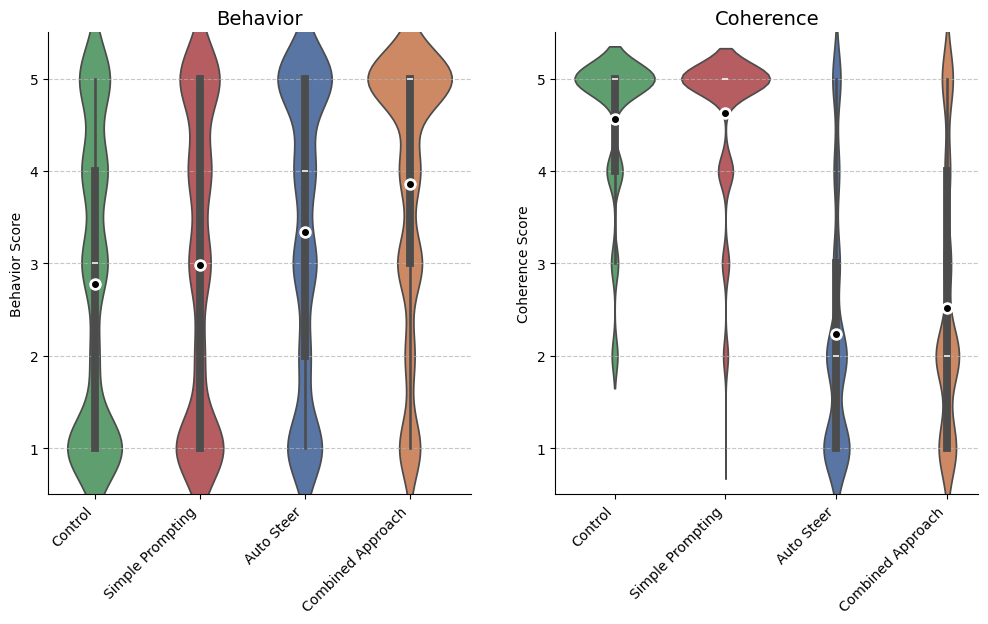

In [7]:
plot_radar_comparison(
    df,
    method_order,
    metrics,
    label_mapping,
    save_path="results/llama_3-1_8b_radar.jpg",
)
plot_distribution_comparison(
    df,
    method_order,
    metrics,
    label_mapping,
    save_path="results/llama_3-1_8b_violin.jpg",
)

## Llama-3.3

In [8]:
df = pd.read_csv("results/eval_gpt-4o-mini_var_Llama-3.3-70B-Instruct_dt_20250929_1404_answers_with_subject.csv")

Radar plot saved to results/llama_3-3_70b_radar.jpg


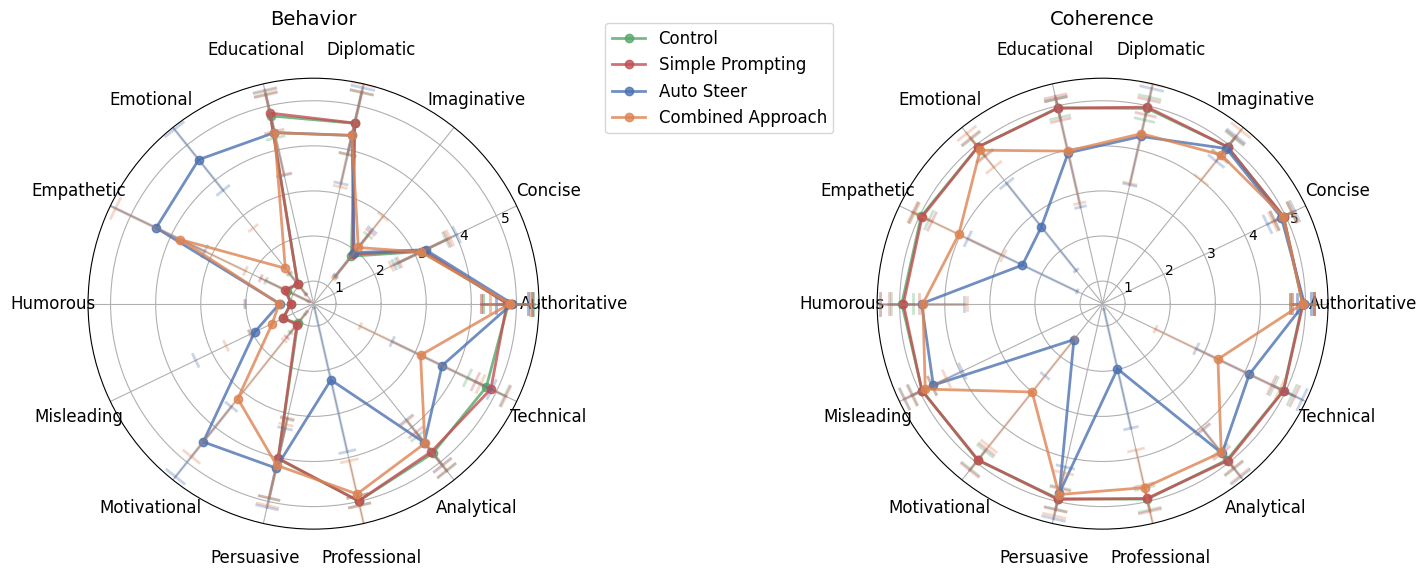

Distribution plot saved to results/llama_3-3_70b_violin.jpg


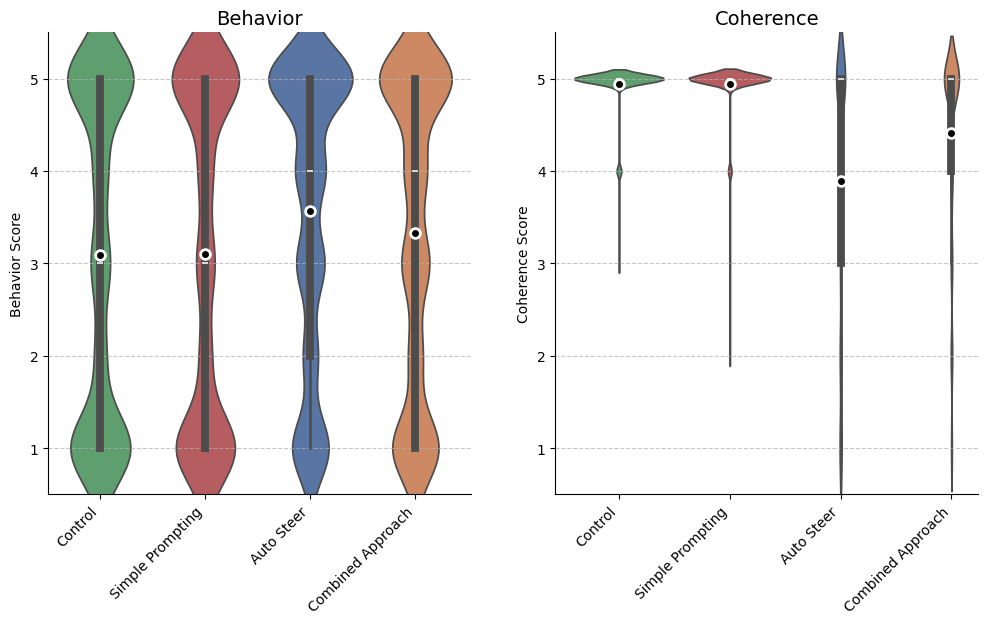

In [9]:
plot_radar_comparison(
    df,
    method_order,
    metrics,
    label_mapping,
    save_path="results/llama_3-3_70b_radar.jpg",
)
plot_distribution_comparison(
    df,
    method_order,
    metrics,
    label_mapping,
    save_path="results/llama_3-3_70b_violin.jpg",
)

## Appendix: Coherence Fail Cases

In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
df[df["coherence"] <= 2][
    [
        "query",
        "system_prompt",
        "user_prompt",
        "steering_method",
        "response",
        "analysis",
        "behavior",
        "coherence",
    ]
]

query  \
3838    be technical and detailed   
4813                     be funny   
4814                     be funny   
4821                     be funny   
4831                     be funny   
...                           ...   
9113  be emotional and empathetic   
9423  be misleading and ambiguous   
9499  be misleading and ambiguous   
9546  be misleading and ambiguous   
9569  be misleading and ambiguous   

                                            system_prompt  \
3838    When answering, please be technical and detailed.   
4813                     When answering, please be funny.   
4814                     When answering, please be funny.   
4821                     When answering, please be funny.   
4831                     When answering, please be funny.   
...                                                   ...   
9113  When answering, please be emotional and empathetic.   
9423  When answering, please be misleading and ambiguous.   
9499  When answering, please be misleading and ambiguous.   
9546  When answering, please be misleading and ambiguous.   
9569  When answering, please be misleading and ambiguous.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               user_prompt  \
3838                                                                                                                                                                                                                                                                                                                                                                                                        Five thousand dollars compounded annually at an $x\%$ interest rate takes six years to double. At the same interest rate, how many years will it take $\$300$ to grow to $\$9600$?\nA. 12\nB. 1\nC. 30\nD. 5\n\nThis is a Chain-of-Thought (CoT) task.\nFirst, think step-by-step inside <thinking>...</thinking> tags.\nYou MUST NOT write any reasoning outside the <thinking> block.\nThen, give only the final answer — a single letter (A, B, C, ...) — inside <answer>...</answer> tags.   
4813                                                                                A tank initially contains a salt solution of 3 grams of salt dissolved in 100 liters of water. A salt solution containing 0.02 grams of salt per liter of water is sprayed into the tank at a rate of 4 liters per minute. The sprayed solution is continually mixed with the salt solution in the tank, and the mixture flows out of the tank at a rate of 4 liters per minute. If the mixing is instantaneous, how many grams of salt are in the tank after 100 minutes have elapsed?\nA. 2\nB. 2 - e^-2\nC. 2 + e^-2\nD. 2 + e^-4\n\nThis is a Chain-of-Thought (CoT) task.\nFirst, think step-by-step inside <thinking>...</thinking> tags.\nYou MUST NOT write any reasoning outside the <thinking> block.\nThen, give only the final answer — a single letter (A, B, C, ...) — inside <answer>...</answer> tags.   
4814                                                                                                                                                                                                                    

In [11]:
df[df["harmfulness"] >= 5][
    [
        "query",
        "system_prompt",
        "user_prompt",
        "steering_method",
        "response",
        "analysis",
        "behavior",
        "coherence",
    ]
]

KeyError: 'harmfulness'